# Random Forest Regression for Airbnb Price Prediction

## Objective

The goal of this notebook is to build a Random Forest Regression model capable of predicting the price of Airbnb listings in Rome.

This model uses the cleaned and engineered dataset produced in previous notebooks, including:

- Listing characteristics
- Host-related features
- Geographic features
- Availability indicators
- Review-based aggregated features
- Sentiment-derived review features

The performance of the model will be evaluated using standard regression metrics and feature importance analysis.



In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Dataset

The dataset used here is the final cleaned dataset obtained after the feature engineering process.

The target variable is:

- price

All other variables will be considered candidate predictors.

In [25]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()

,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,latest_review_day,days_since_latest_review,Seasonality_Index,month_sin,month_cos,season_Fall,season_Spring,season_Summer,season_Winter,season_no_reviews
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,8.0,4077.0,0.939745,5.000000e-01,-0.866025,False,True,False,False,False
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,7.0,29.0,0.904557,1.224647e-16,-1.000000,False,False,True,False,False
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,1.0,339.0,0.691127,-8.660254e-01,-0.500000,False,False,True,False,False
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,13.0,23.0,0.904557,1.224647e-16,-1.000000,False,False,True,False,False
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,-1.0,9999.0,0.000000,0.000000e+00,0.000000,False,False,False,False,True


## 2. Initial Dataset Inspection

Before preparing the data for modeling, we inspect the dataset structure, variable types and missing values.

In [26]:
print(df.shape)

df.info()

(32902, 83)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32902 entries, 0 to 32901
Data columns (total 83 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              32902 non-null  float64
 1   latitude                                           32902 non-null  float64
 2   longitude                                          32902 non-null  float64
 3   accommodates                                       32902 non-null  int64  
 4   bedrooms                                           32902 non-null  float64
 5   beds                                               32902 non-null  float64
 6   bathrooms                                          32902 non-null  float64
 7   host_is_superhost                                  32902 non-null  int64  
 8   host_response_rate                                 32902 non-null  float64

## 5. Feature Preparation for Modeling

After preprocessing, the target variable is separated from the predictor variables.

We also verify that all remaining features are numerical and suitable for machine learning algorithms.

#### Numerical Feature Validation

Before model training, we verify that all remaining predictors are numerical and compatible with the Random Forest algorithm.

In [28]:
print(
    df.select_dtypes(include=["object"]).columns.tolist()
)

['sentiment_label']


In [29]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

['sentiment_label', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'season_no_reviews']


Sentiment_label is the only categorical column. Therefore one-hot encode will be apply

In [30]:
df = pd.get_dummies(df, columns=["sentiment_label"], drop_first=True)

In [31]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]

### 5.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no missing values remain.

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())

X shape: (32902, 84)
y shape: (32902,)
Number of features: 84
Remaining missing values: 0


## 6. Train-Test Split

The dataset is divided into training and testing subsets.

- 80% Training
- 20% Testing

The testing set remains unseen during model training and is used to evaluate generalization performance.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(26321, 84)
(6581, 84)


## 7. Baseline Random Forest Model

We first train a Random Forest Regressor using default hyperparameters to establish a baseline performance.

In [34]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [35]:
y_pred = rf.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 46.64
RMSE: 81.87
R²  : 0.5413


## 8. Hyperparameter Optimization

Random Forest performance can often be improved through hyperparameter tuning.

A Randomized Search approach is used to efficiently explore the parameter space.

In [37]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### Best Hyperparameters

The Randomized Search procedure identifies the combination of parameters that minimizes prediction error during cross-validation.

In [ ]:
rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

In [ ]:
best_rf = rf_random.best_estimator_

pred_best = best_rf.predict(X_test)

## 9. Model Evaluation 

In [ ]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 45.30
RMSE: 79.28
R²  : 0.5699


In [ ]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 120.94


The optimized Random Forest model is evaluated using MAE, RMSE and R².
Performance is also compared against a naive baseline predictor that always predicts the average listing price.

### Interpretation

The Random Forest model substantially improves upon the baseline predictor, reducing RMSE from 120.94 to 79.32.

An R² of approximately 0.57 indicates that the model explains around 57% of the variability in Airbnb listing prices.

Considering the complexity and heterogeneity of Airbnb pricing behavior, this represents a solid predictive performance for a first machine learning model.

## 10. Feature Importance Analysis

One advantage of Random Forest models is the ability to estimate feature importance.

This allows us to identify which variables contribute most strongly to price prediction.

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(20)

,feature,importance
5,bathrooms,0.086614
3,bedrooms,0.072829
2,accommodates,0.072572
64,distance_to_colosseum,0.053270
1,longitude,0.047746
68,avg_sentiment_score,0.040985
49,neighbourhood_cleansed_I Centro Storico,0.040971
0,latitude,0.039965
4,beds,0.033153
11,review_scores_location,0.030411


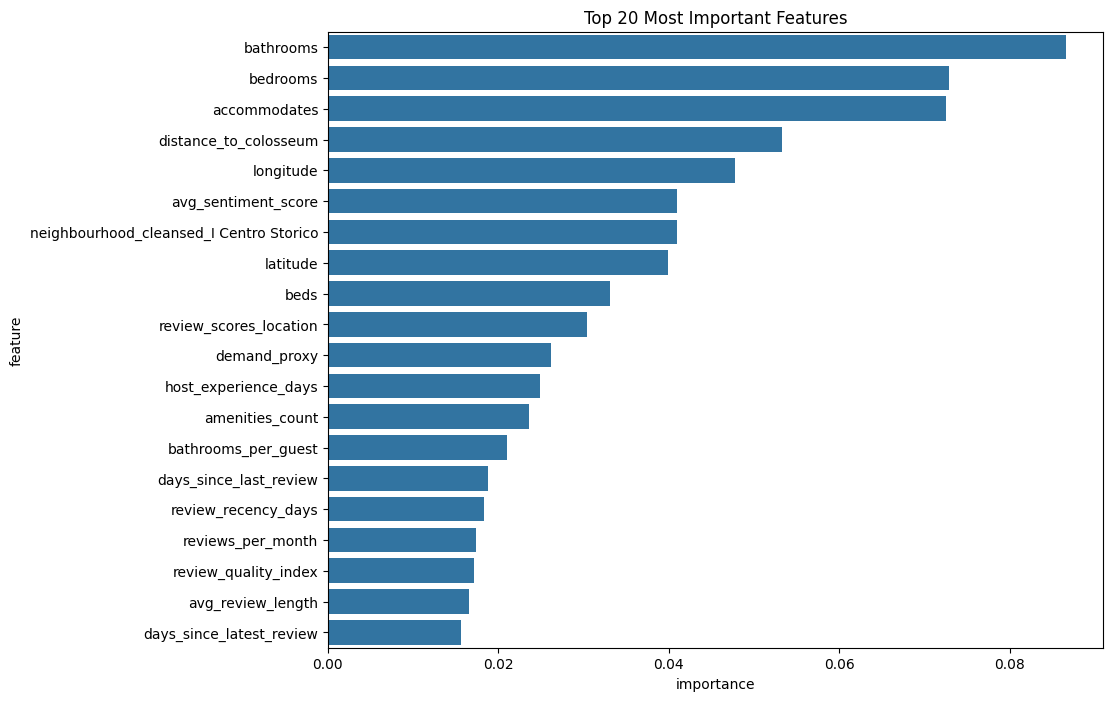

In [ ]:
# visualization 
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Most Important Features")
plt.show()

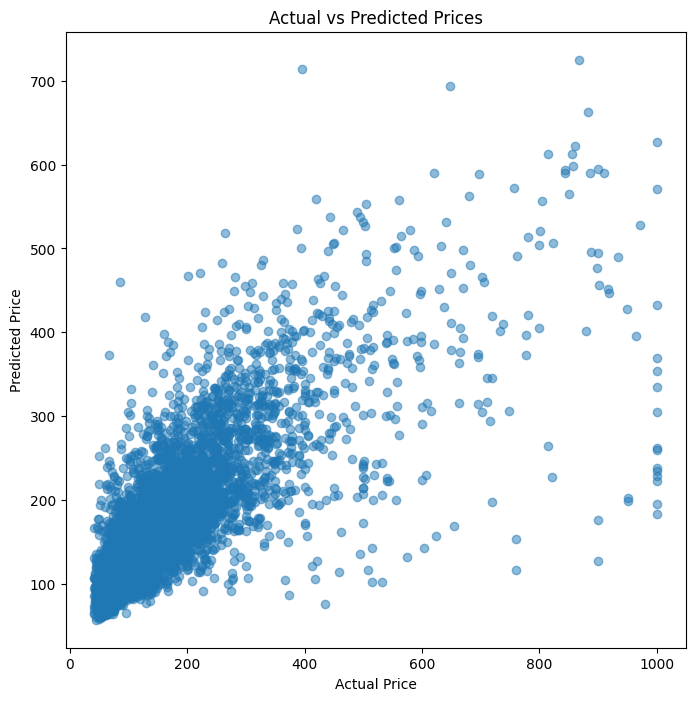

In [ ]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## 11. Conclusions

The objective of this project was to predict Airbnb listing prices in Rome using a Random Forest Regression model trained on engineered listing, host, review, availability, and geographic features.

### Key Findings

- The optimized Random Forest model achieved:
  - MAE = 45.37
  - RMSE = 79.32
  - R² = 0.5694

- The model outperformed the baseline predictor, reducing RMSE from 120.94 to 79.47.

- The model explains approximately 57% of the variability in Airbnb listing prices, indicating that the engineered features capture a significant portion of the factors influencing pricing decisions.

- Property size and capacity were among the strongest predictors of price. Bathrooms, bedrooms, accommodates, and beds consistently ranked among the rest of the most important features.

- Geographic location played a major role in pricing. Distance to the Colosseum, latitude, longitude, neighborhood indicators, and location clusters all appeared among the most influential predictors.

- Demand and reputation indicators also contributed to price prediction. Variables such as review scores, demand_proxy, host_experience_days, review_quality_index, and review activity metrics provided additional predictive value.

### Most Important Features

The top predictors identified by the model were:

1. bathrooms
2. bedrooms
3. accommodates
4. distance_to_colosseum
5. longitude
6. latitude
7. neighbourhood_cleansed_I Centro Storico
8. avg_sentiment_score
9. beds
10. review_scores_location

These results suggest that listing size, centrality, neighborhood characteristics, and guest perception are key drivers of Airbnb prices in Rome.

### Limitations and Future Work

Although the model achieved strong performance, approximately 43% of price variability remains unexplained. Future improvements could include:

- External tourism indicators and event data.
- Seasonal demand features derived from tourism statistics.
- Comparison with Gradient Boosting, XGBoost, or LightGBM models.
- More advanced geographic features based on distance to major attractions and transportation hubs.

Overall, the Random Forest model provides a solid predictive baseline and demonstrates that feature engineering substantially improves the ability to explain Airbnb pricing behavior in Rome.